[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab5/lab5.ipynb)
# Práctica 5: Optimización de redes neuronales


En este laboratorio trabajaremos con el mismo conjunto de datos que hemos utilizado hasta ahora. Carga todo el conjunto en un solo dataloader (en este laboratorio solo nos ocuparemos de estudiar el ajuste en entrenamiento, no la generalización).

In [1]:
# TODO - Carga los datos
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_titanic_raw():
    # 1. Cargamos el dataset Titanic desde seaborn
    df = sns.load_dataset('titanic')

    # Selección de variables relevantes y limpieza
    cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
    df = df[cols].copy()

    # Eliminamos filas con valores faltantes
    df = df.dropna(subset=['age', 'embarked', 'fare'])

    # 2. Separar etiquetas y características
    y = df['survived'].to_numpy().astype(np.float32)
    X = df.drop(columns=['survived'])

    # 3. One-hot encoding para variables categóricas
    categorical_cols = ['pclass', 'sex', 'embarked', 'alone', 'sibsp', 'parch']
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # Convertimos a float32 para PyTorch
    X_np = X_encoded.to_numpy().astype(np.float32)
    y_np = y.reshape(-1, 1).astype(np.float32)

    # Identificamos las columnas numéricas ('age' y 'fare') por sus índices para el escalado posterior
    # En X_encoded, 'age' y 'fare' conservan sus nombres
    numeric_indices = [X_encoded.columns.get_loc('age'), X_encoded.columns.get_loc('fare')]

    return X_np, y_np, numeric_indices

# --- Carga de datos raw ---
X, y, numeric_indices = load_titanic_raw()

# --- 1. Partición en 50% Train, 25% Val, 25% Test ---
# Primera partición: 50% para train, 50% restante para (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# Segunda partición: dividimos el 50% restante a la mitad -> 25% val, 25% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- 2. Escalado sin Data Leakage ---
# Aplicamos StandardScaler usando únicamente las estadísticas calculadas sobre Train
scaler = StandardScaler()

# Ajustamos y transformamos solo en el conjunto de entrenamiento
X_train[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])

# Transformamos val y test usando el escalador ajustado con train
X_val[:, numeric_indices] = scaler.transform(X_val[:, numeric_indices])
X_test[:, numeric_indices] = scaler.transform(X_test[:, numeric_indices])

# --- 3. Conversión a Tensores de PyTorch ---
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)

X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val)

X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

# --- 4. Encapsulado en DataLoaders ---
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Muestras de Entrenamiento: {len(X_train)}")
print(f"Muestras de Validación: {len(X_val)}")
print(f"Muestras de Test: {len(X_test)}")

Muestras de Entrenamiento: 356
Muestras de Validación: 178
Muestras de Test: 178


Usaremos la misma arquitectura, función para el aprendizaje, función para evaluación y función de coste que en los laboratorios anteriores. Haz las declaraciones necesarias en la siguiente celda.

Adapta la función `train_model` para que el parámetro `val_loader` pueda ser `None`, en cuyo caso no se calcula la pérdida en validación y se devuelve una lista vacía en la segunda componente de la tupla.

In [2]:
import matplotlib.pyplot as pyplot

# --- 2. Definición de la Arquitectura de la Red ---
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(20, 10)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(10, 5)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(5, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# --- 3. Declaración de la Función de Pérdida ---
loss_fn = nn.BCEWithLogitsLoss()

# --- 4. Función para evaluar pérdida y accuracy ---
def measure_model(model: nn.Module, loss_fn: nn.modules.loss._Loss, data_loader: data.DataLoader) -> tuple[float, float]:
    """Calcula la pérdida media y la precisión (accuracy) del modelo en un DataLoader dado."""
    model.eval()  # Modo evaluación

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            if isinstance(loss_fn, nn.BCEWithLogitsLoss):
                preds = (outputs >= 0.0).float()
            else:
                preds = (torch.sigmoid(outputs) >= 0.5).float()

            correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples

    return avg_loss, accuracy

# --- 5. Función para entrenar el modelo con Early Stopping ---
def train_model(model: nn.Module,
                optimizer: optim.Optimizer,
                train_loader: data.DataLoader,
                loss_fn: nn.modules.loss._Loss,
                num_epochs: int,
                val_loader: data.DataLoader = None,
                patience: None | int = None) -> tuple[list[float], list[float]]:
    """Entrena el modelo y registra las pérdidas de entrenamiento y validación."""
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()  # Modo entrenamiento
        running_loss = 0.0
        total_train_samples = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            total_train_samples += y_batch.size(0)

        epoch_train_loss = running_loss / total_train_samples
        train_losses.append(epoch_train_loss)

        # Evaluación en validación
        if val_loader is not None:
            val_loss, _ = measure_model(model, loss_fn, val_loader)
            val_losses.append(val_loss)

            # Lógica de Early Stopping
            if patience is not None:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early Stopping activado en la época {epoch + 1} (sin mejora en {patience} épocas).")
                        break

    return train_losses, val_losses

Con todo esto listo, haremos una comparativa de los distintos optimizadores que nos ofrece `torch`.

En primer lugar haremos un entrenamiento con un optimizador SGD sin momentum. Instancia el modelo y un optimizador `optim.SGD`. Haz el entrenamiento y muestra la curva de aprendizaje. Prueba distintos valores de *learning rate*. Guarda las curvas de aprendizaje en un diccionario para mostrarlas todas en un mismo gráfico.

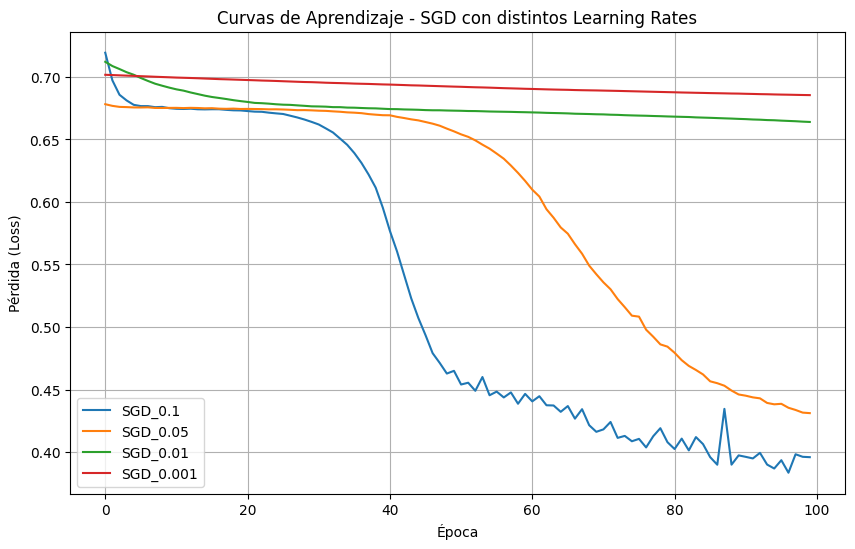

In [5]:
# Definimos el número de características de entrada
input_features = X_train_tensor.shape[1]

lrs_a_explorar = [0.1, 0.05, 0.01, 0.001]
histories = {}

for lr in lrs_a_explorar:
    # 1. Instanciamos un modelo nuevo en cada iteración
    model = SimpleNN(input_features)

    # 2. Creamos el optimizador SGD sin momentum
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # 3. Entrenamos el modelo
    train_losses, _ = train_model(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        loss_fn=loss_fn,
        num_epochs=100,
        val_loader=None,
        patience=None
    )

    # 4. Calculamos el accuracy final en train
    _, train_accuracy = measure_model(model, loss_fn, train_loader)

    # Guarda el history del entrenamiento
    histories[f'SGD_{lr}'] = {'loss_history': train_losses, 'accuracy_history': train_accuracy}

# Mostramos las curvas de aprendizaje en el gráfico
pyplot.figure(figsize=(10, 6))
for k in histories:
    pyplot.plot(histories[k]['loss_history'], label=k)

pyplot.xlabel("Época")
pyplot.ylabel("Pérdida (Loss)")
pyplot.title("Curvas de Aprendizaje - SGD con distintos Learning Rates")
pyplot.legend()
pyplot.grid(True)
pyplot.show()

## Comparativas

Repite todo el proceso de entrenamiento realizando cada uno de estos cambios. Haz varias pruebas hasta encontrar valores adecuados. No resetees el kernel ni vuelvas a ejecutar las dos primeras celdas entre las distintas pruebas, o perderás la posibilidad de comparar las curvas de aprendizaje. Recuerda modificar la etiqueta de la curva de cada prueba en la gráfica cuando añadas registros a `histories`.

1. **Tamaño del lote**: Modifica el tamaño de lote al crear el dataloader y compara los resultados
1. **Learning rate variable**: Vuelve sobre la celda en la que se declara el optimizador y utiliza un [scheduler](https://docs.pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) para que el *learning rate* vaya decayendo linealmente con el tiempo. Utiliza los consejos vistos en teoría para elegir los parámetros. Tendrás que modificar tu función de aprendizaje para que acepte el `scheduler` como parámetro y que llame a su método `step` cuando sea necesario. También es útil mostrar por pantalla el *learning rate* en cada epoch.
1. **Uso de momentum**: Vuelve sobre la celda en la que se declara el optimizador y configúralo para que utilice momentum. Consulta los apuntes y la [documentación](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd) para ayudarte a elegir los hiperparámetros
1. **Otros optimizadores**: Ayúdate de la [documentación](https://docs.pytorch.org/docs/stable/optim.html#algorithms) para probar RMSProp, Adagrad y Adam y compara con los resultados obtenidos hasta ahora.


Ejecutando Experimentos de Batch Size...
Ejecutando Experimentos de SGD...
Ejecutando Experimentos con Otros Optimizadores...


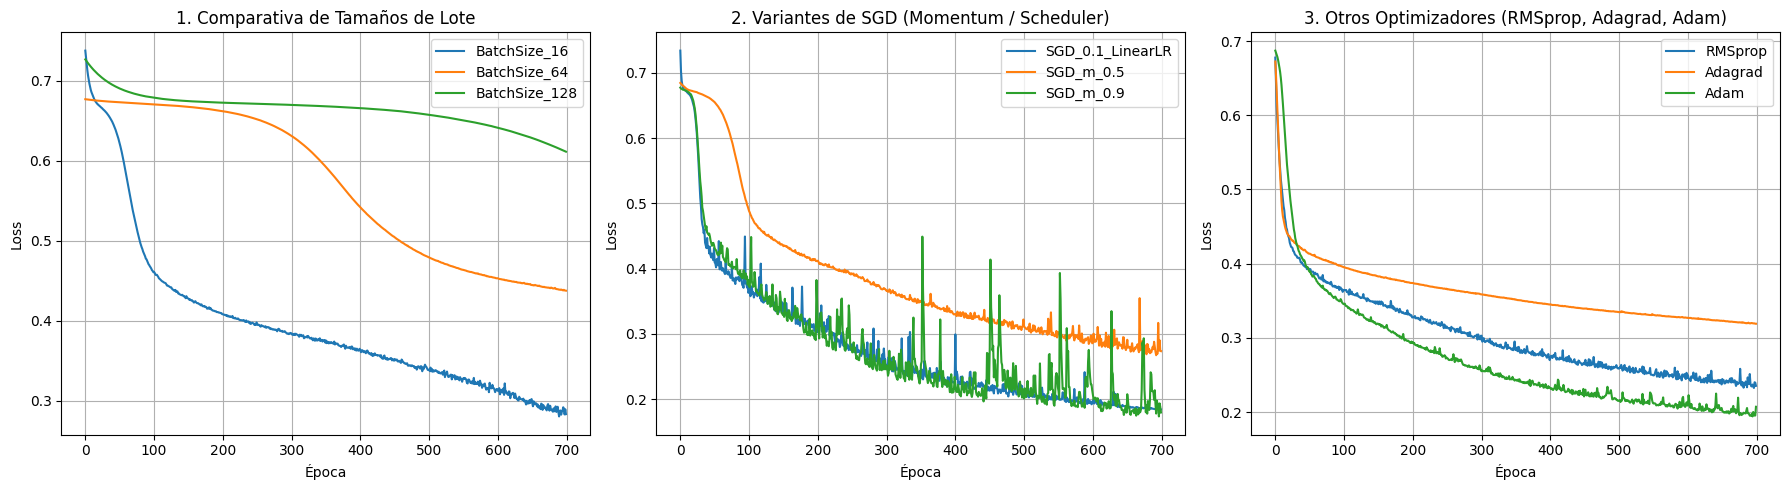


--- ACCURACY FINAL EN TRAINING ---
SGD_0.1              -> Accuracy: 0.8371
SGD_0.05             -> Accuracy: 0.8287
SGD_0.01             -> Accuracy: 0.5955
SGD_0.001            -> Accuracy: 0.5955
BatchSize_16         -> Accuracy: 0.9045
BatchSize_64         -> Accuracy: 0.8062
BatchSize_128        -> Accuracy: 0.6685
SGD_0.1_LinearLR     -> Accuracy: 0.9270
SGD_m_0.5            -> Accuracy: 0.8961
SGD_m_0.9            -> Accuracy: 0.9242
RMSprop              -> Accuracy: 0.8904
Adagrad              -> Accuracy: 0.8736
Adam                 -> Accuracy: 0.9157


In [8]:
# ==============================================================================
# 0. DECLARACIONES BASE
# ==============================================================================

class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(20, 10)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(10, 5)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(5, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

loss_fn = nn.BCEWithLogitsLoss()
input_features = X_train_tensor.shape[1]

def measure_model(model: nn.Module, loss_fn: nn.modules.loss._Loss, data_loader: data.DataLoader) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            if isinstance(loss_fn, nn.BCEWithLogitsLoss):
                preds = (outputs >= 0.0).float()
            else:
                preds = (torch.sigmoid(outputs) >= 0.5).float()

            correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy

def train_model(model: nn.Module,
                optimizer: optim.Optimizer,
                train_loader: data.DataLoader,
                loss_fn: nn.modules.loss._Loss,
                num_epochs: int,
                val_loader: data.DataLoader = None,
                patience: None | int = None,
                scheduler=None) -> tuple[list[float], list[float]]:

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_train_samples = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            total_train_samples += y_batch.size(0)

        epoch_train_loss = running_loss / total_train_samples
        train_losses.append(epoch_train_loss)

        if scheduler is not None:
            scheduler.step()

        if val_loader is not None:
            val_loss, _ = measure_model(model, loss_fn, val_loader)
            val_losses.append(val_loss)

            if patience is not None:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        break

    return train_losses, val_losses


# ==============================================================================
# 1. EJECUCIÓN DE EXPERIMENTOS Y AGRUPACIÓN
# ==============================================================================

if 'histories' not in globals():
    histories = {}

num_epochs = 700

# Diccionarios para separar los 3 grupos solicitados
exp_batch_sizes = {}
exp_sgd_variants = {}
exp_other_optimizers = {}

# --- GRUPO 1: Tamaños de Lote (Batch Size) ---
print("Ejecutando Experimentos de Batch Size...")
for bs in [16, 64, 128]:
    loader_temp = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    model = SimpleNN(input_features)
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    train_losses, _ = train_model(model, optimizer, loader_temp, loss_fn, num_epochs)
    _, train_acc = measure_model(model, loss_fn, loader_temp)

    key = f'BatchSize_{bs}'
    histories[key] = {'loss_history': train_losses, 'accuracy_history': train_acc}
    exp_batch_sizes[key] = train_losses

# --- GRUPO 2: Variantes de SGD (Momentum y Scheduler) ---
print("Ejecutando Experimentos de SGD...")

# SGD con Scheduler
model = SimpleNN(input_features)
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.01, total_iters=num_epochs)
train_losses, _ = train_model(model, optimizer, train_loader, loss_fn, num_epochs, scheduler=scheduler)
_, train_acc = measure_model(model, loss_fn, train_loader)

key = 'SGD_0.1_LinearLR'
histories[key] = {'loss_history': train_losses, 'accuracy_history': train_acc}
exp_sgd_variants[key] = train_losses

# SGD con Momentum
for m in [0.5, 0.9]:
    model = SimpleNN(input_features)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=m)

    train_losses, _ = train_model(model, optimizer, train_loader, loss_fn, num_epochs)
    _, train_acc = measure_model(model, loss_fn, train_loader)

    key = f'SGD_m_{m}'
    histories[key] = {'loss_history': train_losses, 'accuracy_history': train_acc}
    exp_sgd_variants[key] = train_losses

# --- GRUPO 3: Otros Optimizadores (RMSprop, Adagrad, Adam) ---
print("Ejecutando Experimentos con Otros Optimizadores...")
optimizers_to_test = {
    'RMSprop': lambda params: optim.RMSprop(params, lr=0.001),
    'Adagrad': lambda params: optim.Adagrad(params, lr=0.01),
    'Adam': lambda params: optim.Adam(params, lr=0.001)
}

for opt_name, opt_builder in optimizers_to_test.items():
    model = SimpleNN(input_features)
    optimizer = opt_builder(model.parameters())

    train_losses, _ = train_model(model, optimizer, train_loader, loss_fn, num_epochs)
    _, train_acc = measure_model(model, loss_fn, train_loader)

    histories[opt_name] = {'loss_history': train_losses, 'accuracy_history': train_acc}
    exp_other_optimizers[opt_name] = train_losses


# ==============================================================================
# 2. VISUALIZACIÓN AGRUPADA EN 3 GRÁFICAS
# ==============================================================================

fig, axes = pyplot.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Tamaños de Lote (Batch Size)
for key, losses in exp_batch_sizes.items():
    axes[0].plot(losses, label=key)
axes[0].set_title("1. Comparativa de Tamaños de Lote")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Gráfica 2: Variantes de SGD (Momentum + Scheduler)
for key, losses in exp_sgd_variants.items():
    axes[1].plot(losses, label=key)
axes[1].set_title("2. Variantes de SGD (Momentum / Scheduler)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

# Gráfica 3: Otros Optimizadores
for key, losses in exp_other_optimizers.items():
    axes[2].plot(losses, label=key)
axes[2].set_title("3. Otros Optimizadores (RMSprop, Adagrad, Adam)")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("Loss")
axes[2].grid(True)
axes[2].legend()

pyplot.tight_layout()
pyplot.show()

# Resumen numérico
print("\n--- ACCURACY FINAL EN TRAINING ---")
for key, val in histories.items():
    print(f"{key:<20} -> Accuracy: {val['accuracy_history']:.4f}")